In [6]:

import pandas as pd
import os, sys
import glob
import matplotlib.pyplot as plt
import matplotlib.lines as lns
import seaborn as sns
from tqdm import tqdm
import numpy as np
import matplotlib.ticker as mtick
from collections import defaultdict
import matplotlib.dates as mdates


In [7]:
folder = "assets/results"
files = [f for f in os.listdir(folder) if f.endswith(".csv")]

In [8]:
def parse_filename(filename):
    parts = filename.replace(".csv", "").split("_")
    #print(parts)
    if len(parts) == 4:
        sources = 10
        attackers = int(parts[2][1:])
    else:
        attackers = int(parts[3][1:])
        sources = int(parts[2][1:])
    print(sources)
    if "DIOR" in parts:
        mode = "Average"
    elif "MEDIAN" in parts:
        mode = "Median"
    elif sources == 8:
        mode = "ZONIA 0 others"
    elif sources == 10:
        mode = "ZONIA 2 others"
    elif sources == 12:
        mode = "ZONIA 4 others"
    elif sources == 14:
        mode = "ZONIA 6 others"
    else:
        return None
    return filename, attackers, sources, mode

In [9]:
# Dictionary: {(farmer_ratio, mode): count_of_successes}
attack_success_counts = defaultdict(int)
total_counts = defaultdict(int)

for fname in files:
    filepath = os.path.join(folder, fname)
    print(filepath)
    if os.path.getsize(filepath) == 0:
        continue
    df = pd.read_csv(filepath)
    # # Skip files that don't contain the expected column
    # if "consolidated_result" not in df.columns:
    #     continue
    
    parsed_file = parse_filename(fname)
    # raise KeyError()

    if parsed_file is None:
        continue
    _, attacker, _, mode = parsed_file
    
    total_counts[(attacker, mode)] += 1
    if True in df["consolidated_result"].values:
        attack_success_counts[(attacker, mode)] += 1


assets/results/METROAGRIFOR_ZONIA_a0_r7.csv
10
assets/results/METROAGRIFOR_ZONIA_a6_r16.csv
10
assets/results/METROAGRIFOR_DIOR_s8_a5_r17.csv
8
assets/results/METROAGRIFOR_ZONIA_a2_r10.csv
10
assets/results/METROAGRIFOR_ZONIA_s12_a4_r19.csv
12
assets/results/METROAGRIFOR_ZONIA_s12_a4_r1.csv
12
assets/results/METROAGRIFOR_MEDIAN_s8_a1_r15.csv
8
assets/results/METROAGRIFOR_ZONIA_s14_a3_r19.csv
14
assets/results/METROAGRIFOR_MEDIAN_s8_a5_r17.csv
8
assets/results/METROAGRIFOR_ZONIA_s12_a2_r22.csv
12
assets/results/METROAGRIFOR_ZONIA_s8_a6_r10.csv
8
assets/results/METROAGRIFOR_MEDIAN_s8_a6_r9.csv
8
assets/results/METROAGRIFOR_ZONIA_s8_a5_r18.csv
8
assets/results/METROAGRIFOR_ZONIA_s14_a0_r12.csv
14
assets/results/METROAGRIFOR_ZONIA_s8_a1_r13.csv
8
assets/results/METROAGRIFOR_ZONIA_s14_a3_r2.csv
14
assets/results/METROAGRIFOR_ZONIA_s8_a4_r6.csv
8
assets/results/METROAGRIFOR_ZONIA_s12_a6_r26.csv
12
assets/results/METROAGRIFOR_ZONIA_s12_a4_r22.csv
12
assets/results/METROAGRIFOR_ZONIA_s14_a1_r2

defaultdict(<class 'int'>, {(0, 'Median'): 150, (6, 'Median'): 149, (5, 'Average'): 29, (2, 'Median'): 149, (4, 'Median'): 149, (1, 'Median'): 147, (3, 'Median'): 149, (5, 'Median'): 148, (6, 'Average'): 26, (0, 'Average'): 27, (1, 'Average'): 28, (2, 'Average'): 30, (3, 'Average'): 28, (4, 'Average'): 29})


In [10]:
data = []

for (attacker, mode), total in total_counts.items():
    successes = attack_success_counts.get((attacker, mode), 0)
    data.append(
        {
            "attacker": attacker,
            "mode": mode,
            "success_rate": successes / total,
        }
    )

plot_df = pd.DataFrame(data)
print(plot_df)

    attacker            mode  success_rate
0          0  ZONIA 2 others      0.000000
1          6  ZONIA 2 others      0.866667
2          5         Average      0.965517
3          2  ZONIA 2 others      0.000000
4          4  ZONIA 4 others      0.033333
5          1          Median      0.000000
6          3  ZONIA 6 others      0.000000
7          5          Median      0.928571
8          2  ZONIA 4 others      0.000000
9          6  ZONIA 0 others      1.000000
10         6          Median      0.965517
11         5  ZONIA 0 others      0.966667
12         0  ZONIA 6 others      0.000000
13         1  ZONIA 0 others      0.000000
14         4  ZONIA 0 others      0.166667
15         6  ZONIA 4 others      0.133333
16         1  ZONIA 6 others      0.000000
17         6         Average      1.000000
18         0         Average      0.000000
19         5  ZONIA 2 others      0.300000
20         1  ZONIA 2 others      0.000000
21         2  ZONIA 6 others      0.000000
22         

In [11]:

palette = {
    "Average": "#FFC107",
    "Median": "#FF7F50",
    "ZONIA 0 others": "#1B2D41",
    "ZONIA 2 others": "#466C82",
    "ZONIA 4 others": "#87A0B3",
    "ZONIA 6 others": "#D1E1F2",
}

ordered_modes = [
    "Average",
    "Median",
    "ZONIA 0 others",
    "ZONIA 2 others",
    "ZONIA 4 others",
    "ZONIA 6 others",
]
style_config = {
    "Average": {"marker": "s", "linestyle": "--"},
    "Median": {"marker": "^", "linestyle": "-."},
    "ZONIA 0 others": {"marker": "D", "linestyle": ":"},
    "ZONIA 2 others": {"marker": "v", "linestyle": "-"},
    "ZONIA 4 others": {"marker": "P", "linestyle": "--"},
    "ZONIA 6 others": {"marker": "X", "linestyle": "-."},
}

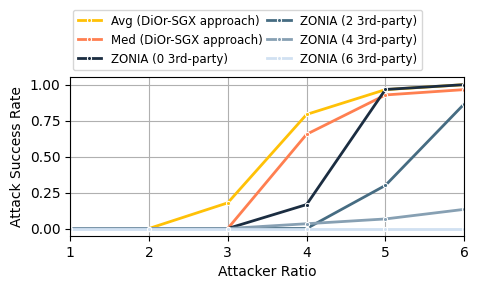

In [12]:
plot_df = plot_df[plot_df["mode"].isin(ordered_modes)].copy()
plot_df["mode"] = pd.Categorical(plot_df["mode"], categories=ordered_modes, ordered=True)
# Plot
plt.figure(figsize=(4.8, 3))
sns.lineplot(
    data=plot_df,
    x="attacker",
    y="success_rate",
    hue="mode",
    palette=palette,
    marker="o",
    markersize=3,
    linewidth=2,
    estimator=None,

)

plt.ylabel("Attack Success Rate")
plt.grid()
plt.xlabel("Attacker Ratio")
plt.xlim(1, 6)

handles, labels = plt.gca().get_legend_handles_labels() 

new_labels = [
     "Avg (DiOr-SGX approach)", "Med (DiOr-SGX approach)", "ZONIA (0 3rd-party)", "ZONIA (2 3rd-party)", "ZONIA (4 3rd-party)", "ZONIA (6 3rd-party)"
]
plt.legend(handles=handles, labels=new_labels,
           bbox_to_anchor=(0.45, 1.01), loc="lower center", ncol=2, columnspacing=0.4, fontsize=8.5)
plt.tight_layout()
plt.savefig("metro.pdf", format="pdf", bbox_inches="tight")


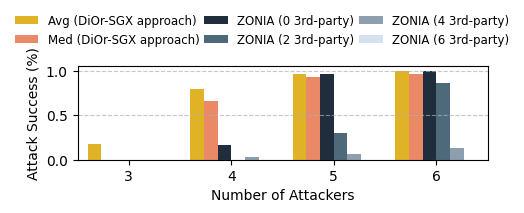

In [13]:
plot_df = plot_df[plot_df["mode"].isin(ordered_modes)].copy()
plot_df["mode"] = pd.Categorical(plot_df["mode"], categories=ordered_modes, ordered=True)

# Plot
plt.figure(figsize=(5, 2))

# Create the bar plot
# The palette will be automatically mapped by seaborn if 'mode' is categorical
# and its categories match the keys in the palette dictionary.
sns.barplot(
    data=plot_df,
    x="attacker",
    y="success_rate",
    hue="mode", # Use the original 'mode' column for hue
    palette=palette, # Pass the palette dictionary directly
    # estimator=np.mean, # Default, use if your data needs aggregation
    # errorbar=None, # Set to None if you don't want error bars or data is pre-aggregated
    dodge=True
)

plt.ylabel("Attack Success (%)")
plt.xlim(2.5)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Optional: add horizontal grid
plt.xlabel("Number of Attackers")
# plt.xlim(1, 6) # For bar plots, x-axis is categorical. If you need to set limits,
                 # it's often better to ensure your 'attacker' data covers the range
                 # or use plt.xticks for specific tick locations if 'attacker' values are not continuous.
                 # If 'attacker' values are 1,2,3,4,5,6, seaborn should handle them well.

# Legend handling
# Get current handles and labels generated by seaborn
handles, _ = plt.gca().get_legend_handles_labels() # We only need handles, new_labels will be used

# Use the provided new_labels for the legend
plt.legend(
    handles=handles, # Use handles from the plot
    labels=new_labels, # Use your custom new_labels
    title="Mode",      # Optional: add a title to the legend
    bbox_to_anchor=(0.5, 1.15), # Adjust as needed
    loc="upper center",
    ncol=2, # Adjust based on number of labels
    columnspacing=0.4,
    fontsize=8.5
)

plt.tight_layout(rect=[0, 0, 1, 0.92]) # Adjust rect to make space for legend if it's outside
plt.legend(handles=handles, labels=new_labels, frameon=False,
           bbox_to_anchor=(0.45, 1.1), loc="lower center", ncol=3, columnspacing=0.4, fontsize=8.5)

plt.savefig("metro_bar.png", format="png", bbox_inches="tight")
# plt.show() # Uncomment to display the plot interactively

ValueError: Could not interpret value `farmer_ratio` for `x`. An entry with this name does not appear in `data`.

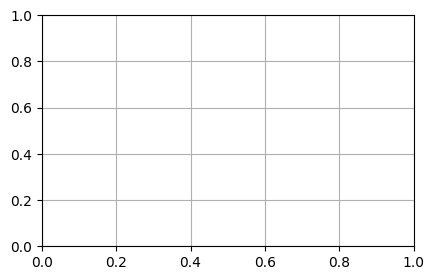

In [14]:
plot_df = plot_df[plot_df["mode"].isin(ordered_modes)].copy()
plot_df["mode"] = pd.Categorical(plot_df["mode"], categories=ordered_modes, ordered=True)

# Plot
plt.figure(figsize=(4.8, 3))
plt.grid()

sns.lineplot(
    data=plot_df,
    x="farmer_ratio",
    y="success_rate",
    hue="mode",
    palette=palette,
    marker="o",
    markersize=3,
    linewidth=2,
    estimator=None,
)

plt.ylabel("Attack Success Rate")
plt.xlabel("Attacker Ratio")
plt.xlim(0.2, 0.7)

handles, labels = plt.gca().get_legend_handles_labels()

# Split the legend items into two groups
group1_handles = handles[:3]
group1_labels = ["Single (Chainlink approach)", "Avg (DiOr-SGX approach)", "Med (DiOr-SGX approach)"]

group2_handles = handles[3:]
group2_labels = ["ZONIA (0% 3rd-party)", "ZONIA (10% 3rd-party)", "ZONIA (20% 3rd-party)", "ZONIA (30% 3rd-party)"]

# Create two separate legend objects
first_legend = plt.legend(group1_handles, group1_labels, 
                          loc='lower center', bbox_to_anchor=(0.20, 1.13),
                         ncol=1, fontsize=9, frameon=False)
plt.gca().add_artist(first_legend)

plt.legend(group2_handles, group2_labels, 
          loc='lower center', bbox_to_anchor=(0.75, 1),
          ncol=1, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("use_case.png", format="png", bbox_inches="tight", dpi=600)


In [15]:

def plot_indexer_reputations(csv_filepath: str, indexer_ids_to_plot: list[int]):
    """
    Reads a CSV file with indexer reputation data over time and plots the
    reputation for specified indexers.

    The CSV is expected to have:
    - A 'current_time' column as the first column.
    - Subsequent columns named '1', '2', ..., 'N' for indexer reputations.
    - Further columns like '1_data', '2_data', ..., 'N_data' for other data (ignored for this plot).

    Args:
        csv_filepath (str): The path to the CSV file.
        indexer_ids_to_plot (list[int]): A list of indexer IDs (e.g., [1, 2, ..., 8])
                                         whose reputations should be plotted.
    """
    try:
        # Read the CSV file
        # Convert 'current_time' to datetime objects directly during parsing
        df = pd.read_csv(csv_filepath, parse_dates=['current_time'])
    except FileNotFoundError:
        print(f"Error: File not found at {csv_filepath}")
        return
    except Exception as e:
        print(f"Error reading or parsing CSV file: {e}")
        return

    # Set 'current_time' as the index for easier plotting
    df.set_index('current_time', inplace=True)

    # Select only the columns for the specified indexer reputations
    # Column names for reputations are expected to be strings like '1', '2', etc.
    reputation_cols_to_plot = [str(idx_id) for idx_id in indexer_ids_to_plot]

    # Check if all requested columns exist
    missing_cols = [col for col in reputation_cols_to_plot if col not in df.columns]
    if missing_cols:
        print(f"Warning: The following reputation columns were not found in the CSV: {missing_cols}")
        # Filter out missing columns to avoid errors
        reputation_cols_to_plot = [col for col in reputation_cols_to_plot if col in df.columns]
        if not reputation_cols_to_plot:
            print("Error: None of the specified indexer reputation columns are available for plotting.")
            return
            
    # Convert reputation columns to numeric, coercing errors to NaN
    for col in reputation_cols_to_plot:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Create the plot
    plt.figure(figsize=(12, 7)) # Adjust figure size as needed

    # Use seaborn for potentially nicer aesthetics if you like
    # sns.set_theme(style="whitegrid") # Example theme

    for col_name in reputation_cols_to_plot:
        plt.plot(df.index, df[col_name], marker='o', linestyle='-', markersize=4, label=f'Indexer {col_name}')
        # Or using seaborn lineplot for each:
        # sns.lineplot(data=df, x=df.index, y=col_name, marker='o', markersize=4, label=f'Indexer {col_name}')


    # Formatting the plot
    plt.title('Indexer Reputations Over Time')
    plt.xlabel('Time')
    plt.ylabel('Reputation')

    # Format the x-axis to display dates nicely
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=10)) # Adjust tick density
    
    plt.xticks(rotation=30, ha='right') # Rotate date labels for readability

    plt.legend(title='Indexers', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend

    # Save the plot (optional)
    output_filename = "indexer_reputations.png"
    plt.savefig(output_filename, format="png", bbox_inches="tight")
    print(f"Plot saved to {output_filename}")

    plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np # Import numpy

def plot_indexer_reputations_and_data(csv_filepath: str, indexer_ids_to_plot: list[int]):
    """
    Reads a CSV file and plots indexer reputations and their corresponding
    '_data' values over time in a two-column figure.
    Features a single, centralized legend at the top.
    X-axis shows Month-Day.

    Args:
        csv_filepath (str): The path to the CSV file.
        indexer_ids_to_plot (list[int]): A list of indexer IDs
                                         whose reputations and data should be plotted.
    """
    try:
        df = pd.read_csv(csv_filepath)
        # Explicitly parse 'current_time'. If your times are already UTC or have offsets,
        # pandas to_datetime should handle them well.
        df['current_time'] = pd.to_datetime(df['current_time'], errors='coerce')
        df.dropna(subset=['current_time'], inplace=True)
        if df.empty:
            print("Error: No valid datetime entries found in 'current_time' column after parsing.")
            return
    except FileNotFoundError:
        print(f"Error: File not found at {csv_filepath}")
        return
    except KeyError:
        print(f"Error: 'current_time' column not found in {csv_filepath}")
        return
    except Exception as e:
        print(f"Error reading or parsing CSV file: {e}")
        return

    reputation_cols_to_plot = [str(idx_id) for idx_id in indexer_ids_to_plot]
    data_cols_to_plot = [f"{idx_id}_data" for idx_id in indexer_ids_to_plot]

    # Prepare data for plotting (convert to numeric)
    for col in reputation_cols_to_plot + data_cols_to_plot:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Check if there's anything to plot
    valid_reputation_cols = [col for col in reputation_cols_to_plot if col in df.columns and not df[col].isnull().all()]
    valid_data_cols_present = any(col in df.columns and not df[col].isnull().all() for col in data_cols_to_plot)

    if not valid_reputation_cols and not valid_data_cols_present:
        print("Error: No valid reputation or data columns with non-null data found for plotting.")
        return
    min_time = df['current_time'].min()
    max_time = df['current_time'].max()
    fig, axes = plt.subplots(1, 2, figsize=(13, 2)) # Slightly increased height for legend space

    # Store handles and labels for the combined legend
    legend_handles = []
    legend_labels = []

    # --- Plot 1: Reputations ---
    if valid_reputation_cols:
        x_times = np.array(df['current_time'].dt.to_pydatetime())
        for col_name in valid_reputation_cols:
            line, = axes[0].plot(x_times, df[col_name], linestyle='-')
            if f'WS #{col_name}' not in legend_labels: # Add to legend only if not already added by data plot
                legend_handles.append(line)
                legend_labels.append(f'WS #{col_name}') # Distinguish reputation lines

        axes[0].set_xlabel('Date (Month-Day)', fontsize=9)
        axes[0].set_ylabel('Reputation', fontsize=9)
        axes[0].tick_params(axis='x', rotation=30, labelsize=8)
        axes[0].tick_params(axis='y', labelsize=8)
        axes[0].grid(True, linestyle='--', alpha=0.7)
        axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d')) # Month-Day format
        axes[0].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=5))
        axes[0].set_ylim(-0.8, 1.0) # Corrected from xlim to ylim
        axes[0].set_xlim(min_time , max_time )

    else:
        axes[0].text(0.5, 0.5, 'No reputation data.', ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_xlabel('Date (Month-Day)', fontsize=9)
    # --- Plot 2: Data ---
    if valid_data_cols_present:
        x_times = np.array(df['current_time'].dt.to_pydatetime()) # x_times is the same
        for col_name in data_cols_to_plot:
            if col_name in df.columns and not df[col_name].isnull().all():
                try:
                    indexer_id_str = col_name.split('_')[0]
                    label_text = f'WS #{indexer_id_str}' # Data lines will use this label format
                    # Check if this label (without distinguishing rep/data) is already in legend_labels
                    # to potentially reuse handles or decide if a new handle is needed.
                    # For simplicity, if we want separate entries for rep/data, always add.
                    # If we want one entry per WS#, and different linestyles, it's more complex.
                    # Current request: "Maintain the one that is written WS #{id}" -> implies data lines define the primary legend item.
                    
                    # If reputation for this indexer_id_str was NOT plotted, or we want distinct legend entries:
                    # if label_text not in legend_labels:
                    #     line, = axes[1].plot(x_times, df[col_name], linestyle='--')
                    #     #legend_handles.append(line)
                    #     #legend_labels.append(label_text)
                    # else: # Label exists, assume it's from reputation plot, just plot data
                    axes[1].plot(x_times, df[col_name], linestyle='--')

                except IndexError:
                    pass # Should not happen

        axes[1].set_xlabel('Date (Month-Day)', fontsize=9)
        axes[1].set_ylabel('Temperature (Celsius)', fontsize=9) # Assuming Temperature, adjust if generic
        axes[1].tick_params(axis='x', rotation=30, labelsize=8)
        axes[1].tick_params(axis='y', labelsize=8)
        axes[1].grid(True, linestyle='--', alpha=0.7)
        axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d')) # Month-Day format
        axes[1].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=5))
        axes[1].set_xlim(min_time , max_time )

    else:
        axes[1].text(0.5, 0.5, 'No data values.', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_xlabel('Date (Month-Day)', fontsize=9)

    # --- Combined Legend on Top ---
    if legend_handles:
        # Sort handles and labels together if needed, e.g., by indexer ID
        # For now, using the order they were added.
        # Max number of columns for legend, e.g., 4 or 5, depending on number of items
        ncol_legend = min(len(legend_labels), 4) 
        fig.legend(legend_handles, legend_labels, loc='upper center', 
                   bbox_to_anchor=(0.5, 1.05), ncol=8,  frameon=False)

    # No individual titles for subplots if using a common legend and suptitle
    axes[0].set_title('')
    axes[1].set_title('')
    
    # fig.suptitle('Indexer Monitoring', fontsize=12) # Optional: if you want an overall title below legend
    #plt.tight_layout(rect=[0, 0, 1, 0.90]) # Adjust rect to make space for the top legend

    output_filename = "source_monitoring_without_attack.png"
    plt.savefig(output_filename, format="png", bbox_inches="tight")
    print(f"Plot saved to {output_filename}")

    plt.show()

/tmp/ipykernel_1991/1231206517.py:62: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  x_times = np.array(df['current_time'].dt.to_pydatetime())
/tmp/ipykernel_1991/1231206517.py:84: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  x_times = np.array(df['current_time'].dt.to_pydatetime()) # x_times is the same


Plot saved to source_monitoring_with_attack.png


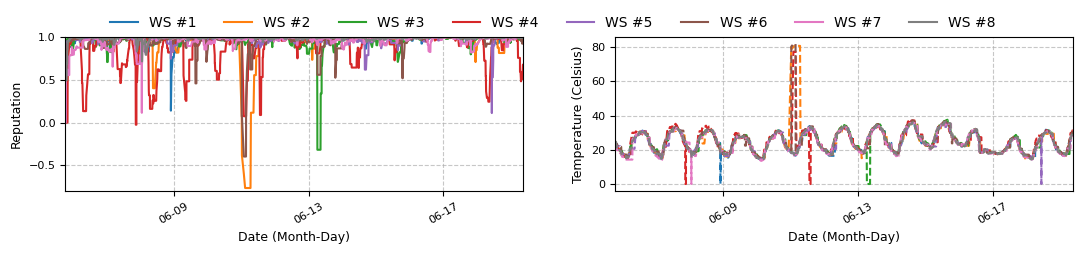

In [ ]:
plot_indexer_reputations_and_data("indexers_0.csv", [1,2,3,4,5,6,7,8])
#plot_indexer_reputations_and_data("indexers_4.csv", [1,2,3,4,5,6,7,8])